# XTCAV: Raw Data Visualization: Show First Pulse Per Run
# Single Pulse, Runs 10-18

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from utils import (
    load_xtcav_run_first_pulse,
    get_com,
    get_xtcav_mask,
    get_com_clean,
    get_plot_lims
)

## Run 10 (double pulse)

In [2]:
# set the run number
runnum=10

# set zoom-in FOV
Lx = 240
Ly = 340

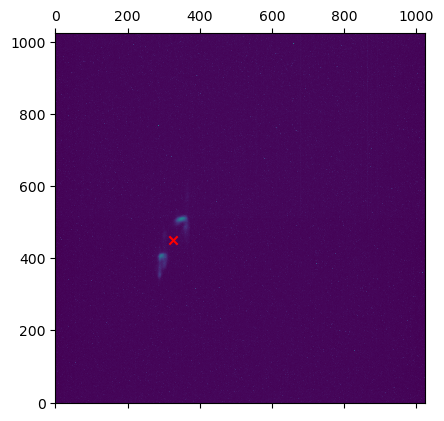

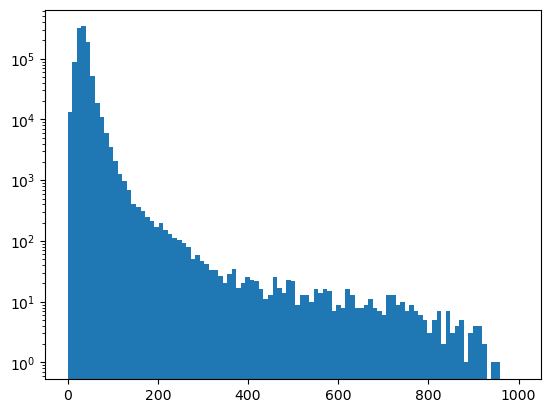

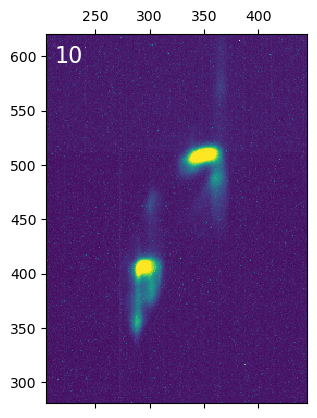

In [3]:
# load data
image,success=load_xtcav_run_first_pulse(runnum)
# get CoM
com = get_com_clean(image)

# show camera capture
fig,ax = plt.subplots()
ax.matshow(image)
ax.scatter(com[1],com[0],marker='x',color='r')
ax.invert_yaxis()
plt.show()

# show histogram
fig,ax = plt.subplots()
ax.hist(image.ravel(),bins=np.linspace(0,1000,100))
ax.semilogy()
plt.show()

# show camera capture - zoom in
fig,ax = plt.subplots()
ax.matshow(image,vmin=0,vmax=5e2)
ax.set_xlim(get_plot_lims(com[1],Lx))
ax.set_ylim(get_plot_lims(com[0],Ly))
ax.text(0.03,0.97,f"{runnum}",size=16,color='w',ha='left',va='top',transform=ax.transAxes)
plt.show()

## Runs 11-18 (single pulse)

In [4]:
# Set parameters

# run numbers
runnums = np.arange(11,19)

# zoom-in FOV
Lx = 150
Ly = 240

# contrast
vmin,vmax = 0,5e2

In [5]:
# Populate data

# set up storage
s = image.shape
n = (len(runnums))
ims = np.empty((n,s[0],s[1]))
coms = np.empty((n,2))

# get data
for idx,runnum in enumerate(runnums):
    # load
    image,success=load_xtcav_run_first_pulse(runnum)
    # get CoM
    com = get_com_clean(image)
    # store
    ims[idx] = image
    coms[idx] = com

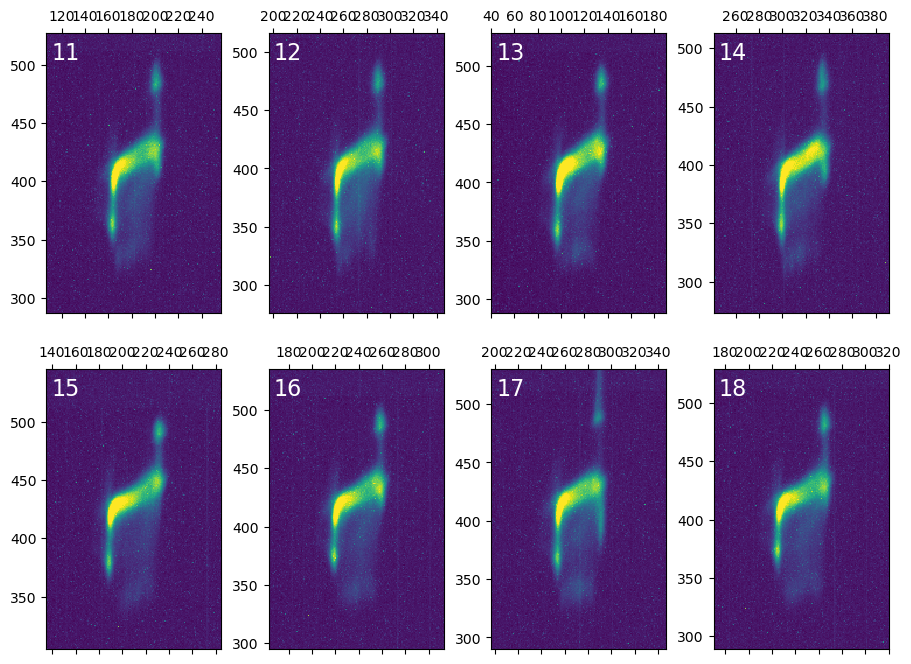

In [6]:
# show

# make plot
fig,axs = plt.subplots(2,4,figsize=(11,8))
for idx,runnum in enumerate(runnums):
    # get axis
    axi = idx//4
    axj = idx%4
    ax = axs[axi,axj]
    # get data
    im = ims[idx]
    com = coms[idx]
    # show
    ax.matshow(im,vmin=vmin,vmax=vmax)
    ax.set_xlim(get_plot_lims(com[1],Lx))
    ax.set_ylim(get_plot_lims(com[0],Ly))
    # run numbers
    ax.text(0.03,0.97,f"{runnums[idx]}",size=16,color='w',ha='left',va='top',transform=ax.transAxes)

plt.show()